In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
import pandas as pd
import conductivity as cd

# Equivalent Conductivity Model

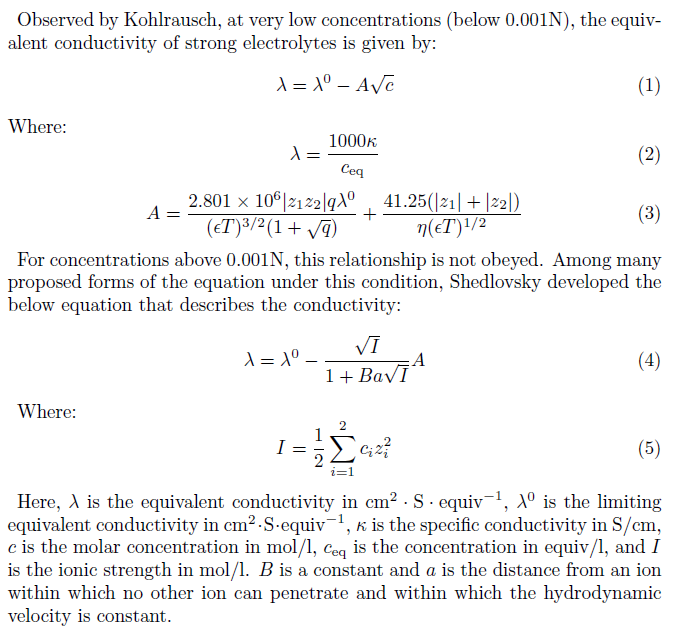

Robinson, R. A., & Stokes, R. H. (2002). Electrolyte solutions. Courier Corporation.

# Data

In [2]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl.csv")
molar_conc_specific_Na = specific_data["NaCl conc"]
specific_cond_exp_Na = specific_data["NaCl cond"]
specific_cond_calibrated_Na = specific_data["NaCl cond cal"]

# measurement error
error_Na = (-0.00007 * molar_conc_specific_Na + 0.0102) * specific_cond_calibrated_Na
error_Na_uncal = (-0.00007 * molar_conc_specific_Na + 0.0102) * specific_cond_exp_Na

# number of data points
ndata_Na = len(specific_cond_exp_Na)

In [3]:
# loading CaCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CaCl2.csv")
molar_conc_specific_Ca_fig = specific_data["CaCl2_conc"]
specific_cond_exp_Ca = specific_data["CaCl2_cond"]
specific_cond_calibrated_Ca_fig = specific_data["CaCl2_cond_cal"]

# measurement error
error_Ca = (-0.00007 * molar_conc_specific_Ca_fig + 0.0102) * specific_cond_calibrated_Ca_fig
error_Ca_uncal = (-0.00007 * molar_conc_specific_Ca_fig + 0.0102) * specific_cond_exp_Ca

# number of data points
ndata_Ca_fig = len(specific_cond_calibrated_Ca_fig)

In [4]:
# loading LaCl3 specific conductivity data
specific_data = pd.read_csv("./Data/LaCl3_2.csv")
molar_conc_specific_La_fig = specific_data["LaCl3 conc"]
specific_cond_exp_La = specific_data["LaCl3 cond"]
specific_cond_calibrated_La_fig = specific_data["LaCl3 cond cal"]

# measurement error
error_La = (-0.00007 * molar_conc_specific_La_fig + 0.0102) * specific_cond_calibrated_La_fig
error_La_uncal = (-0.00007 * molar_conc_specific_La_fig + 0.0102) * specific_cond_exp_La

# number of data points
ndata_La_fig = len(specific_cond_calibrated_La_fig)

In [5]:
# loading KCl specific conductivity data
specific_data_probe1 = pd.read_csv("./Data/KCl_Probe1.csv")
specific_data_probe2 = pd.read_csv("./Data/KCl_Probe2.csv")
specific_data_probe3 = pd.read_csv("./Data/KCl_Probe3.csv")

molar_conc_specific = specific_data_probe1["KCl Conc"]

specific_cond_exp1 = specific_data_probe1["Cond"]
specific_cond_calibrated_exp1 = specific_data_probe1["Cond_cal"]
specific_cond_exp2 = specific_data_probe2["Cond"]
specific_cond_exp3 = specific_data_probe3["Cond"]

# measurement error
error_K = (-0.00007 * molar_conc_specific + 0.0102) * specific_cond_calibrated_exp1
error_K_uncal = (-0.00007 * molar_conc_specific + 0.0102) * specific_cond_exp1
error_K_uncal_2 = (-0.00007 * molar_conc_specific + 0.0102) * specific_cond_exp2

# number of data points
ndata_K = len(specific_cond_exp1)

# load the NIST standards
nist_standard = pd.read_csv("./Data/NIST_KCl.csv")
molar_conc_nist = nist_standard["KCl Conc"]
nist_cond = nist_standard["NIST Cond"]
error_nist = 0.0025 * nist_cond

# MSA Specific Conductivity

In [6]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_K = 1.957 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_K = 1

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_K = 2 * 138 * 10**(-12)

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_K_mol = 73.48 * 10**(-4)

## NaCl

In [7]:
# constants
diff_coeff_na_cl = [Diff_Na, Diff_Cl] # diffusion coefficients of Na and Cl, respectively
valency_na_cl = [z_Na, z_Cl] # valencies of Na and Cl, respectively
diameter_na_cl = [sigma_Na, sigma_Cl] # effective ionic diameters of Na and Cl, respectively
lambda_0_na_cl = [lambda_0_Na_mol, lambda_0_Cl_mol] # limiting molar conductivity of Na and Cl, respectively

# predicted conductivity in uS/cm
msa_cond_calc_nacl =cd.msa_transport(valency_na_cl, diameter_na_cl, diff_coeff_na_cl, T, eta_msa, epsilon, lambda_0_na_cl, molar_conc_specific_Na)

Relaxation correction: [-0.04592817 -0.04592817]
Hydrodynamic correction: [-0.15303697 -0.09425016]
omega_bar: 408747984038.1848
Alpha: [0.0, 399863050037.51556]
Mew: [0.5 0.5]
Transport number: [0.3963161 0.6036839]
Omega: [3.23986816e+11 4.93509152e+11]
ksi: [[ 1.23419544 -1.        ]
 [ 0.81024445  1.        ]]


## KCl

In [8]:
# constants
diff_coeff_k_cl = [Diff_K, Diff_Cl] # diffusion coefficients of K and Cl, respectively
valency_k_cl = [z_K, z_Cl] # valencies of K and Cl, respectively
diameter_k_cl = [sigma_K, sigma_Cl] # effective ionic diameters of K and Cl, respectively
lambda_0_k_cl = [lambda_0_K_mol, lambda_0_Cl_mol] # limiting molar conductivity of K and Cl, respectively

# predicted conductivity in uS/cm
msa_cond_calc_kcl =cd.msa_transport(valency_k_cl, diameter_k_cl, diff_coeff_k_cl, T, eta_msa, epsilon, lambda_0_k_cl, molar_conc_specific)

Relaxation correction: [-0.04348786 -0.04348786]
Hydrodynamic correction: [-0.09967594 -0.09280948]
omega_bar: 484401577043.46985
Alpha: [0.0, 484315950503.33417]
Mew: [0.5 0.5]
Transport number: [0.49059915 0.50940085]
Omega: [4.75294002e+11 4.93509152e+11]
ksi: [[ 1.01898183 -1.        ]
 [ 0.98137177  1.        ]]


## CaCl2

In [9]:
# constants
diff_coeff_ca_cl = [Diff_Ca, Diff_Cl] # diffusion coefficients of K and Cl, respectively
valency_ca_cl = [z_Ca, z_Cl] # valencies of K and Cl, respectively
diameter_ca_cl = [sigma_Ca, sigma_Cl] # effective ionic diameters of K and Cl, respectively
lambda_0_ca_cl = [lambda_0_Ca_mol, lambda_0_Cl_mol] # limiting molar conductivity of K and Cl, respectively

# predicted conductivity in uS/cm
msa_cond_calc_cacl2 =cd.msa_transport(valency_ca_cl, diameter_ca_cl, diff_coeff_ca_cl, T, eta_msa, epsilon, lambda_0_ca_cl, molar_conc_specific_Ca_fig)

Relaxation correction: [-0.10818585 -0.10818585]
Hydrodynamic correction: [-0.39791399 -0.14075783]
omega_bar: 292737712474.16846
Alpha: [0.0, 357043456714.2952]
Mew: [0.66666667 0.33333333]
Transport number: [0.4380531 0.5619469]
Omega: [1.92351992e+11 4.93509152e+11]
ksi: [[ 1.38221033 -0.61018268]
 [ 0.53873552  1.22036535]]


## LaCl3

In [10]:
# constants
diff_coeff_la_cl = [Diff_La, Diff_Cl] # diffusion coefficients of La and Cl, respectively
valency_la_cl = [z_La, z_Cl] # valencies of La and Cl, respectively
diameter_la_cl = [sigma_La, sigma_Cl] # effective ionic diameters of La and Cl, respectively
lambda_0_la_cl = [lambda_0_La_mol, lambda_0_Cl_mol] # limiting molar conductivity of La and Cl, respectively

# predicted conductivity in uS/cm
msa_cond_calc_lacl3 =cd.msa_transport(valency_la_cl, diameter_la_cl, diff_coeff_la_cl, T, eta_msa, epsilon, lambda_0_la_cl, molar_conc_specific_La_fig)

Relaxation correction: [-0.12637157 -0.12637157]
Hydrodynamic correction: [-0.41013329 -0.11737156]
omega_bar: 236129071587.12134
Alpha: [0.0, 357917325038.36115]
Mew: [0.75 0.25]
Transport number: [0.47750064 0.52249936]
Omega: [1.50335711e+11 4.93509152e+11]
ksi: [[ 1.37883561 -0.43937499]
 [ 0.42002915  1.31812498]]


## Plotting the results

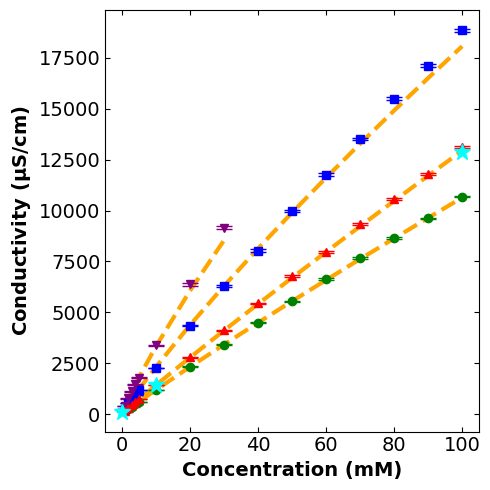

In [11]:
# making plot comparison of probe 1 calibrated data and the calculated values
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
plt.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='NaCl Data')
plt.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
plt.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', capsize=6, markersize=6, 
    markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
plt.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='KCl Data')
plt.plot(molar_conc_nist, nist_cond, "*", markersize=12, color="cyan", zorder=3, label="NIST (KCl) Standard")
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_single_all.png")
plt.show()

The mean absolute percent error of KCl is: 1.4624924405185529
The mean absolute percent error of NaCl is: 1.009129270787198
The mean absolute percent error of CaCl2 is: 2.282134652190118
The mean absolute percent error of LaCl3 is: 2.2050559761670034

The mean absolute error of KCl is: 47.171464657418106
The mean absolute error of NaCl is: 16.84671084030268
The mean absolute error of CaCl2 is: 179.30074306210764
The mean absolute error of LaCl3 is: 132.47502832921228

The mean squared error of KCl is: 4474.9535744255445
The mean squared error of NaCl is: 614.2780014165954
The mean squared error of CaCl2 is: 94669.89290551633
The mean squared error of LaCl3 is: 63465.33898915735


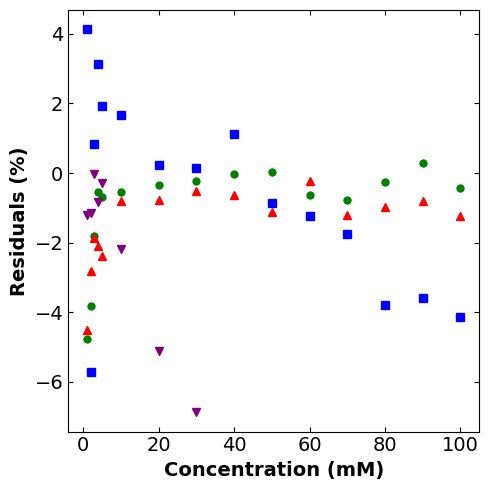

In [12]:
# residuals of the MSA model predictions
e_K_fig_MSA = [msa_cond_calc_kcl[i]- specific_cond_calibrated_exp1[i] for i in range(ndata_K)]
e_Na_fig_MSA = [msa_cond_calc_nacl[i]- specific_cond_calibrated_Na[i] for i in range(ndata_Na)]
e_Ca_fig_MSA = [msa_cond_calc_cacl2[i] - specific_cond_calibrated_Ca_fig[i] for i in range(ndata_Ca_fig)]
e_La_fig_MSA = [msa_cond_calc_lacl3[i] - specific_cond_calibrated_La_fig[i] for i in range(ndata_La_fig)]

# relative error
residuals_percent_K_MSA = [100*e_K_fig_MSA[i]/specific_cond_calibrated_exp1[i] for i in range(ndata_K)]
residuals_percent_Na_MSA = [100*e_Na_fig_MSA[i]/specific_cond_calibrated_Na[i] for i in range(ndata_Na)]
residuals_percent_Ca_MSA = [100*e_Ca_fig_MSA[i]/specific_cond_calibrated_Ca_fig[i] for i in range(ndata_Ca_fig)]
residuals_percent_La_MSA = [100*e_La_fig_MSA[i]/specific_cond_calibrated_La_fig[i] for i in range(ndata_La_fig)]

# calculate mean absolute prediction errors
residuals_percent_K_abs_MSA = [np.abs(residuals_percent_K_MSA[i]) for i in range(ndata_K)]
residuals_percent_Na_abs_MSA = [np.abs(residuals_percent_Na_MSA[i]) for i in range(ndata_Na)]
residuals_percent_Ca_abs_MSA = [np.abs(residuals_percent_Ca_MSA[i]) for i in range(ndata_Ca_fig)]
residuals_percent_La_abs_MSA = [np.abs(residuals_percent_La_MSA[i]) for i in range(ndata_La_fig)]
print("The mean absolute percent error of KCl is:",np.mean(residuals_percent_K_abs_MSA))
print("The mean absolute percent error of NaCl is:",np.mean(residuals_percent_Na_abs_MSA))
print("The mean absolute percent error of CaCl2 is:",np.mean(residuals_percent_Ca_abs_MSA))
print("The mean absolute percent error of LaCl3 is:",np.mean(residuals_percent_La_abs_MSA))

# calculate the mean absolute error
residuals_K_abs_MSA = [np.abs(e_K_fig_MSA[i]) for i in range(ndata_K)]
residuals_Na_abs_MSA = [np.abs(e_Na_fig_MSA[i]) for i in range(ndata_Na)]
residuals_Ca_abs_MSA = [np.abs(e_Ca_fig_MSA[i]) for i in range(ndata_Ca_fig)]
residuals_La_abs_MSA = [np.abs(e_La_fig_MSA[i]) for i in range(ndata_La_fig)]
print("\nThe mean absolute error of KCl is:",np.mean(residuals_K_abs_MSA))
print("The mean absolute error of NaCl is:",np.mean(residuals_Na_abs_MSA))
print("The mean absolute error of CaCl2 is:",np.mean(residuals_Ca_abs_MSA))
print("The mean absolute error of LaCl3 is:",np.mean(residuals_La_abs_MSA))

# calculate the mean squared error
sq_residuals_K_MSA = [e_K_fig_MSA[i]**2 for i in range(ndata_K)]
sq_residuals_Na_MSA = [e_Na_fig_MSA[i]**2 for i in range(ndata_Na)]
sq_residuals_Ca_MSA = [e_Ca_fig_MSA[i]**2 for i in range(ndata_Ca_fig)]
sq_residuals_La_MSA = [e_La_fig_MSA[i]**2 for i in range(ndata_La_fig)]
print("\nThe mean squared error of KCl is:",np.mean(sq_residuals_K_MSA))
print("The mean squared error of NaCl is:",np.mean(sq_residuals_Na_MSA))
print("The mean squared error of CaCl2 is:",np.mean(sq_residuals_Ca_MSA))
print("The mean squared error of LaCl3 is:",np.mean(sq_residuals_La_MSA))

# plot of the residuals of the MSA specific conductivity
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific_Na, residuals_percent_Na_MSA, "g.", markersize=10, label="NaCl")
plt.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca_MSA, "s", color="blue", label="CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific, residuals_percent_K_MSA, "^", color="red", label="KCl")
plt.plot(molar_conc_specific_La_fig, residuals_percent_La_MSA, "v", color="purple", label="LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
# plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\MSA_single_all_residuals.png")
plt.show()

# Variant Shedlovsky Specific Conductivity

## NaCl

In [13]:
# loading NaCl equivalent conductivity data
equiv_data = pd.read_csv("./Data/NaCl_equiv.csv")
molar_conc_equiv = equiv_data["Conc"] # mM
equiv_cond = equiv_data["Equiv_cond"] # cm^2.Siemen.equiv^(-1)

# number of data points
ndata = len(equiv_cond)

# constants
eta_shed = 8.9*10**(-3) # poise
lambda_0_NaCl = 126.45 # cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_NaCl = 4*10**(-8) # cm
z_Na = 1
z_Cl = -1

In [14]:
# concentration in M
conc_Na = [molar_conc_specific_Na[i]*10**(-3) for i in range(ndata_Na)]
conc_Ca_fig = [molar_conc_specific_Ca_fig[i]*10**(-3) for i in range(ndata_Ca_fig)]
conc_La_fig = [molar_conc_specific_La_fig[i]*10**(-3) for i in range(ndata_La_fig)]

# NaCl specific conductivity in micro Siemen per cm
specific_cond_calc_Na = cd.variant_shedlovsky(conc_Na, T, epsilon, eta_shed, lambda_0_NaCl, a_NaCl, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

# CaCl2 constants
lambda_0_CaCl2 = 135.85 # cm^2.Siemen.equiv^(-1)
a_CaCl2 = 4.31*10**(-8) # cm
lambda_0_Ca = 59.5 # cm^2.Siemen.equiv^(-1)
z_Ca = 2

# CaCl2 specific conductivity in micro Siemen per cm
specific_cond_calc_Ca_fig = cd.variant_shedlovsky(conc_Ca_fig, T, epsilon, eta_shed, lambda_0_CaCl2, a_CaCl2, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)

# LaCl3 constants
lambda_0_LaCl3 = 145.9 # cm^2.Siemen.equiv^(-1)
a_LaCl3 = 4.9*10**(-8) # cm
lambda_0_La = 69.7 # cm^2.Siemen.equiv^(-1)
z_La = 3

# LaCl3 specific conductivity in micro Siemen per cm
specific_cond_calc_La_fig = cd.variant_shedlovsky(conc_La_fig, T, epsilon, eta_shed, lambda_0_LaCl3, a_LaCl3, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

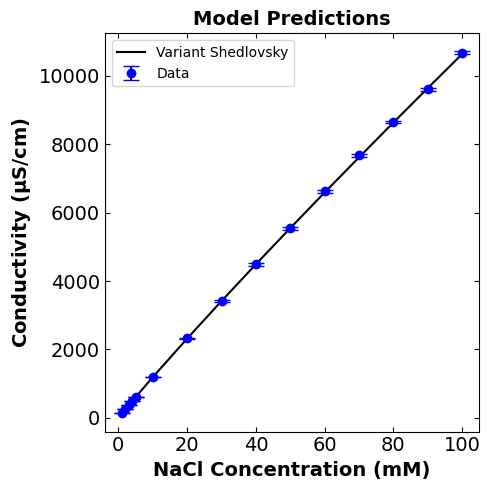

In [15]:
# making plot comparison of the calibrated data and the calculated values
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", color="black", label="Variant Shedlovsky")
plt.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='Data')
plt.xlabel("NaCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Model Predictions", fontsize=14,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

The mean absolute percent error of NaCl is: 0.9578943261524507
The mean absolute percent error of CaCl2 is: 2.203846864393019
The mean absolute percent error of LaCl3 is: 1.8915399288355634

The mean absolute error of NaCl is: 15.682313592034848
The mean absolute error of CaCl2 is: 155.88251307151592
The mean absolute error of LaCl3 is: 114.06894200512463

The mean squared error of NaCl is: 512.3522639819097
The mean squared error of CaCl2 is: 70214.53882210904
The mean squared error of LaCl3 is: 48026.55413220505


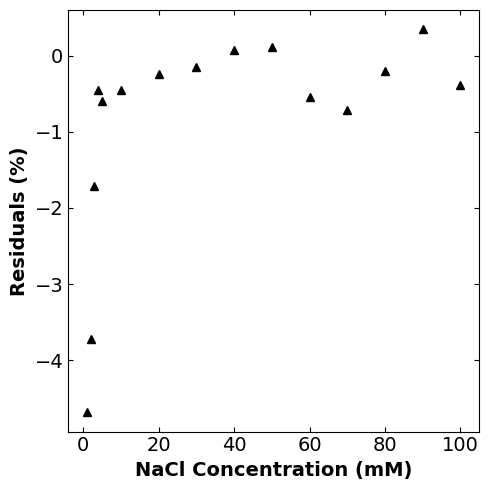

In [16]:
# residuals of the calibrated data
e_Na_fig = [specific_cond_calc_Na[i]- specific_cond_calibrated_Na[i] for i in range(ndata_Na)]
e_Ca_fig = [specific_cond_calc_Ca_fig[i] - specific_cond_calibrated_Ca_fig[i] for i in range(ndata_Ca_fig)]
e_La_fig = [specific_cond_calc_La_fig[i] - specific_cond_calibrated_La_fig[i] for i in range(ndata_La_fig)]

# relative error
residuals_percent_Na = [100*e_Na_fig[i]/specific_cond_calibrated_Na[i] for i in range(ndata_Na)]
residuals_percent_Ca = [100*e_Ca_fig[i]/specific_cond_calibrated_Ca_fig[i] for i in range(ndata_Ca_fig)]
residuals_percent_La = [100*e_La_fig[i]/specific_cond_calibrated_La_fig[i] for i in range(ndata_La_fig)]

# calculate the mean absolute percent error
residuals_percent_Na_abs = [np.abs(residuals_percent_Na[i]) for i in range(ndata_Na)]
residuals_percent_Ca_abs = [np.abs(residuals_percent_Ca[i]) for i in range(ndata_Ca_fig)]
residuals_percent_La_abs = [np.abs(residuals_percent_La[i]) for i in range(ndata_La_fig)]
print("The mean absolute percent error of NaCl is:",np.mean(residuals_percent_Na_abs))
print("The mean absolute percent error of CaCl2 is:",np.mean(residuals_percent_Ca_abs))
print("The mean absolute percent error of LaCl3 is:",np.mean(residuals_percent_La_abs))

# calculate the mean absolute error
residuals_Na_abs = [np.abs(e_Na_fig[i]) for i in range(ndata_Na)]
residuals_Ca_abs = [np.abs(e_Ca_fig[i]) for i in range(ndata_Ca_fig)]
residuals_La_abs = [np.abs(e_La_fig[i]) for i in range(ndata_La_fig)]
print("\nThe mean absolute error of NaCl is:",np.mean(residuals_Na_abs))
print("The mean absolute error of CaCl2 is:",np.mean(residuals_Ca_abs))
print("The mean absolute error of LaCl3 is:",np.mean(residuals_La_abs))

# calculate the mean squared error
sq_residuals_Na = [e_Na_fig[i]**2 for i in range(ndata_Na)]
sq_residuals_Ca = [e_Ca_fig[i]**2 for i in range(ndata_Ca_fig)]
sq_residuals_La = [e_La_fig[i]**2 for i in range(ndata_La_fig)]
print("\nThe mean squared error of NaCl is:",np.mean(sq_residuals_Na))
print("The mean squared error of CaCl2 is:",np.mean(sq_residuals_Ca))
print("The mean squared error of LaCl3 is:",np.mean(sq_residuals_La))

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific_Na, residuals_percent_Na, "^", color="black")
plt.xlabel("NaCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
plt.show()

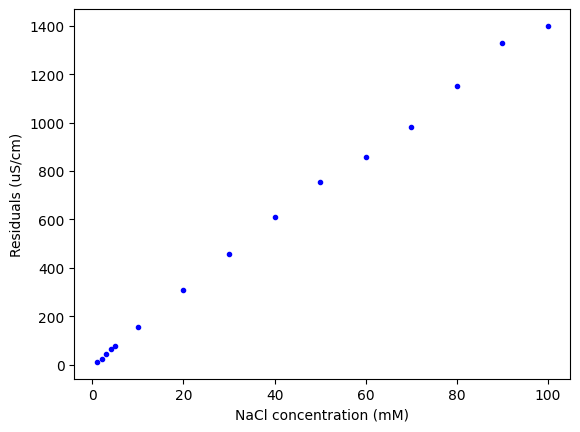

In [17]:
# residuals of the uncalibrated data
residuals = [specific_cond_calc_Na[i] - specific_cond_exp_Na[i] for i in range(ndata_Na)]

# making plot of residuals of calculated specific conductivity
plt.plot(molar_conc_specific_Na, residuals, "b.")
plt.xlabel("NaCl concentration (mM)")
plt.ylabel("Residuals (uS/cm)")
plt.show()

14.556094783314133


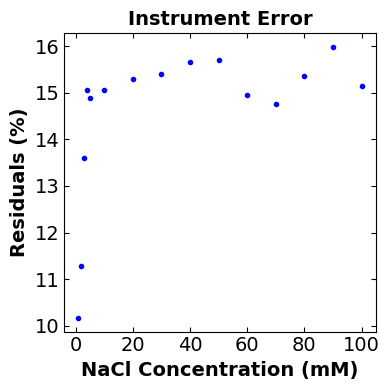

In [18]:
# residual fraction of the uncalibrated data
residuals_percent_Na_uncal = [(residuals[i]/specific_cond_exp_Na[i])*100 for i in range(ndata_Na)]

# residuals percent average
residual_percent_avg = np.average(residuals_percent_Na_uncal)
print(residual_percent_avg)

# visualizing in plot
fig = plt.figure(figsize=(4,4))
plt.plot(molar_conc_specific_Na, residuals_percent_Na_uncal, "b.")
plt.xlabel("NaCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Instrument Error", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## KCl Probe 1

In [19]:
# loading KCl equivalent conductivity data
equiv_data = pd.read_csv("./Data/KCl_Equiv.csv")
molar_conc_equiv = equiv_data["KCl Conc"] # mM
equiv_cond = equiv_data["Equiv Cond"] # cm^2.Siemen.equiv^(-1)

# number of data points
ndata = len(equiv_cond)

# constants
lambda_0_KCl = 149.85 # cm^2.Siemen.equiv^(-1)
lambda_0_K = 73.50 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_KCl = 4.6*10**(-8) # cm
z_K = 1 # cation valency
z_Cl = -1 # anion valency

In [20]:
# concentration in M
conc_K = [molar_conc_specific[i]*10**(-3) for i in range(ndata_K)]

# specific conductivity in micro Siemen per cm
specific_cond_calc = cd.variant_shedlovsky(conc_K, T, epsilon, eta_shed, lambda_0_KCl, a_KCl, z_K, z_Cl, lambda_0_K, lambda_0_Cl)

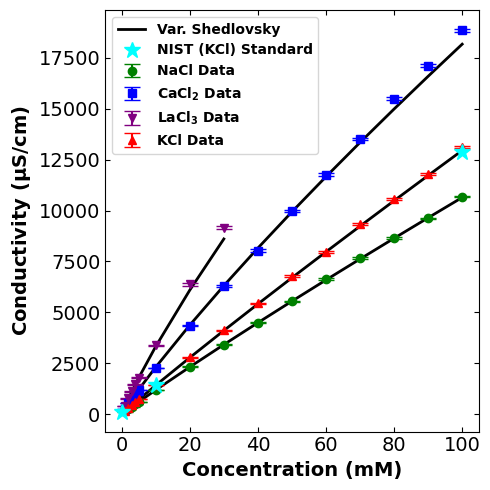

In [21]:
# making plot comparison of probe 1 calibrated data and the calculated values
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=2, label="Var. Shedlovsky")
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=2, color="black")
plt.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", linewidth=2, color="black")
plt.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", linewidth=2, color="black")
plt.plot(molar_conc_nist, nist_cond, "*", markersize=12, color="cyan", zorder=3, label="NIST (KCl) Standard")
plt.errorbar(
    molar_conc_specific_Na, specific_cond_calibrated_Na, yerr=error_Na, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='NaCl Data')
plt.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_calibrated_Ca_fig, yerr=error_Ca, fmt='s', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
plt.errorbar(
    molar_conc_specific_La_fig, specific_cond_calibrated_La_fig, yerr=error_La, fmt='v', ecolor='purple', capsize=6, markersize=6, 
    markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
plt.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp1, yerr=error_K, fmt='^', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='KCl Data')
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\var_shed_all.png")
plt.show()

The mean absolute percent error of KCl is: 1.3726749102955749

The mean absolute error of KCl is: 42.810484583823175

The mean squared error of KCl is: 3820.266010296541


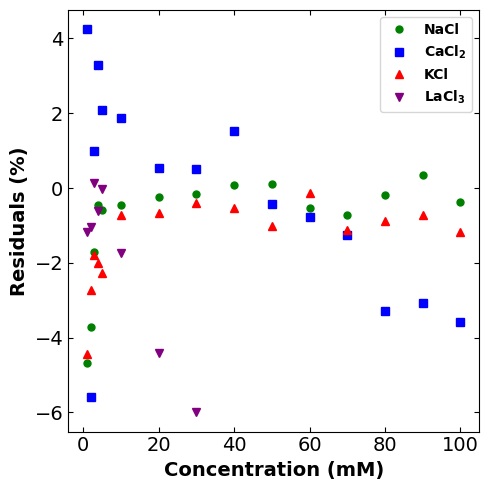

In [22]:
# residuals of the calibrated probe 1 data
e_K_fig = [specific_cond_calc[i] - specific_cond_calibrated_exp1[i] for i in range(ndata_K)]

# percent error
residuals_percent_K = [100*e_K_fig[i]/specific_cond_calibrated_exp1[i] for i in range(ndata_K)]

# calculate mean absolute percent error
residuals_percent_K_abs = [np.abs(residuals_percent_K[i]) for i in range(ndata_K)]
print("The mean absolute percent error of KCl is:",np.mean(residuals_percent_K_abs))

# calculate the mean absolute error
residuals_K_abs = [np.abs(e_K_fig[i]) for i in range(ndata_K)]
print("\nThe mean absolute error of KCl is:",np.mean(residuals_K_abs))

# calculate the mean squared error
sq_residuals_K = [e_K_fig[i]**2 for i in range(ndata_K)]
print("\nThe mean squared error of KCl is:",np.mean(sq_residuals_K))

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific_Na, residuals_percent_Na, "g.", markersize=10, label="NaCl")
plt.plot(molar_conc_specific_Ca_fig, residuals_percent_Ca, "s", color="blue", label="CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific, residuals_percent_K, "^", color="red", label="KCl")
plt.plot(molar_conc_specific_La_fig, residuals_percent_La, "v", color="purple", label="LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\var_shed_all_residuals.png")
plt.show()

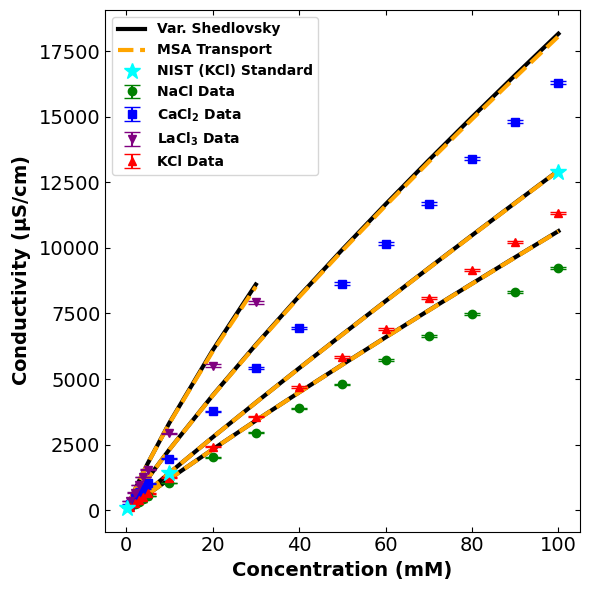

In [23]:
# making plot comparison of probe 1 uncalibrated data and the model predictions
fig = plt.figure(figsize=(6, 6))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(molar_conc_specific_Na, specific_cond_calc_Na, "-", linewidth=3, color="black")
plt.plot(molar_conc_specific_Ca_fig, specific_cond_calc_Ca_fig, "-", color="black", linewidth=3)
plt.plot(molar_conc_specific_La_fig, specific_cond_calc_La_fig, "-", color="black", linewidth=3)
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(molar_conc_specific_Na, msa_cond_calc_nacl, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_Ca_fig, msa_cond_calc_cacl2, "--", color="orange", linewidth=3)
plt.plot(molar_conc_specific_La_fig, msa_cond_calc_lacl3, "--", color="orange", linewidth=3)
plt.plot(molar_conc_nist, nist_cond, "*", markersize=12, color="cyan", zorder=3, label="NIST (KCl) Standard")
plt.errorbar(
    molar_conc_specific_Na, specific_cond_exp_Na, yerr=error_Na_uncal, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='NaCl Data')
plt.errorbar(
    molar_conc_specific_Ca_fig, specific_cond_exp_Ca, yerr=error_Ca_uncal, fmt='s', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='CaCl$\mathbf{_2}$ Data')
plt.errorbar(
    molar_conc_specific_La_fig, specific_cond_exp_La, yerr=error_La_uncal, fmt='v', ecolor='purple', capsize=6, markersize=6, 
    markerfacecolor='purple', markeredgecolor='purple', label='LaCl$\mathbf{_3}$ Data')
plt.errorbar(
    molar_conc_specific, specific_cond_exp1, yerr=error_K_uncal, fmt='^', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='KCl Data')
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_uncal.png")
plt.show()

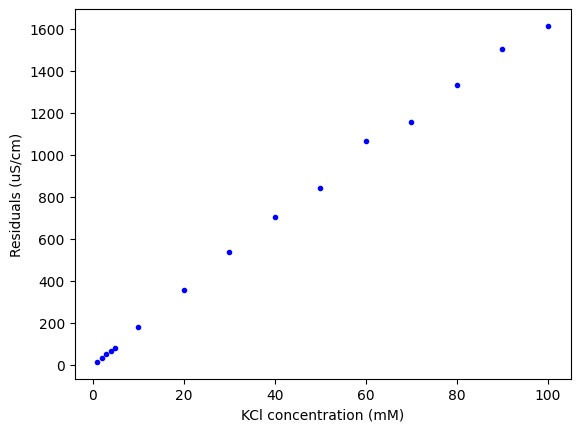

In [24]:
# residuals of the uncalibrated probe 1 data
residuals_uncal = [specific_cond_calc[i] - specific_cond_exp1[i] for i in range(ndata_K)]
e_Ca_uncal = [specific_cond_calc_Ca_fig[i] - specific_cond_exp_Ca[i] for i in range(ndata_Ca_fig)]
e_La_uncal = [specific_cond_calc_La_fig[i] - specific_cond_exp_La[i] for i in range(ndata_La_fig)]

# residuals of the MSA model
residuals_uncal_MSA = [msa_cond_calc_kcl[i] - specific_cond_exp1[i] for i in range(ndata_K)]
e_Na_uncal_MSA = [msa_cond_calc_nacl[i] - specific_cond_exp_Na[i] for i in range(ndata_Na)]
e_Ca_uncal_MSA = [msa_cond_calc_cacl2[i] - specific_cond_exp_Ca[i] for i in range(ndata_Ca_fig)]
e_La_uncal_MSA = [msa_cond_calc_lacl3[i] - specific_cond_exp_La[i] for i in range(ndata_La_fig)]

# making plot of residuals of calculated specific conductivity
plt.plot(molar_conc_specific, residuals_uncal, "b.")
plt.xlabel("KCl concentration (mM)")
plt.ylabel("Residuals (uS/cm)")
plt.show()

The average percent error for KCl is: 13.993462338680375


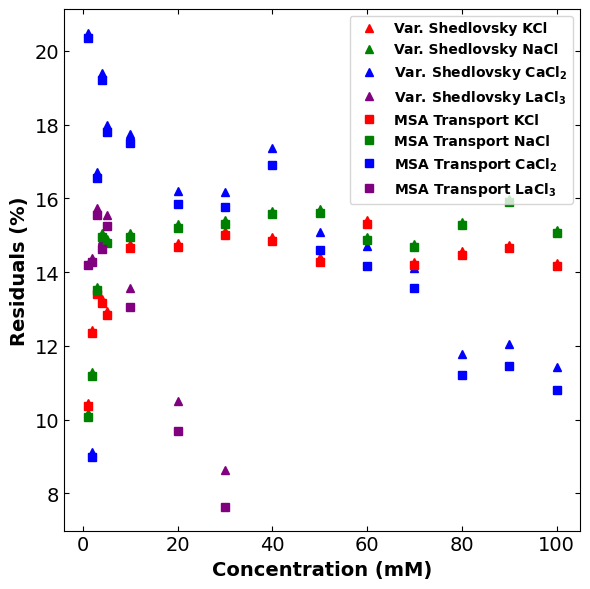

In [25]:
# residual fraction of the uncalibrated probe 1 data
residuals_percent_uncal = [(residuals_uncal[i]/specific_cond_exp1[i])*100 for i in range(ndata_K)]
e_percent_Ca_uncal = [100*e_Ca_uncal[i]/specific_cond_exp_Ca[i] for i in range(ndata_Ca_fig)]
e_percent_La_uncal = [100*e_La_uncal[i]/specific_cond_exp_La[i] for i in range(ndata_La_fig)]

# percent error of MSA
residuals_percent_uncal_MSA = [(residuals_uncal_MSA[i]/specific_cond_exp1[i])*100 for i in range(ndata_K)]
e_percent_Na_uncal_MSA = [100*e_Na_uncal_MSA[i]/specific_cond_exp_Na[i] for i in range(ndata_Na)]
e_percent_Ca_uncal_MSA = [100*e_Ca_uncal_MSA[i]/specific_cond_exp_Ca[i] for i in range(ndata_Ca_fig)]
e_percent_La_uncal_MSA = [100*e_La_uncal_MSA[i]/specific_cond_exp_La[i] for i in range(ndata_La_fig)]

# KCl percent error average
residual_percent_avg = np.average(residuals_percent_uncal)
print("The average percent error for KCl is:",residual_percent_avg)

# visualizing in plot
fig = plt.figure(figsize=(6, 6))
plt.plot(molar_conc_specific, residuals_percent_uncal, "^", color="red", label="Var. Shedlovsky KCl")
plt.plot(molar_conc_specific_Na, residuals_percent_Na_uncal, "^", color="green", label="Var. Shedlovsky NaCl")
plt.plot(molar_conc_specific_Ca_fig, e_percent_Ca_uncal, "^", color="blue", label="Var. Shedlovsky CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_La_fig, e_percent_La_uncal, "^", color="purple", label="Var. Shedlovsky LaCl$\mathbf{_3}$")
plt.plot(molar_conc_specific, residuals_percent_uncal_MSA, "s", color="red", label="MSA Transport KCl")
plt.plot(molar_conc_specific_Na, e_percent_Na_uncal_MSA, "s", color="green", label="MSA Transport NaCl")
plt.plot(molar_conc_specific_Ca_fig, e_percent_Ca_uncal_MSA, "s", color="blue", label="MSA Transport CaCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_La_fig, e_percent_La_uncal_MSA, "s", color="purple", label="MSA Transport LaCl$\mathbf{_3}$")
plt.xlabel("Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_residuals_uncal.png")
plt.show()

## KCl Probe 2

### Uncalibrated Data

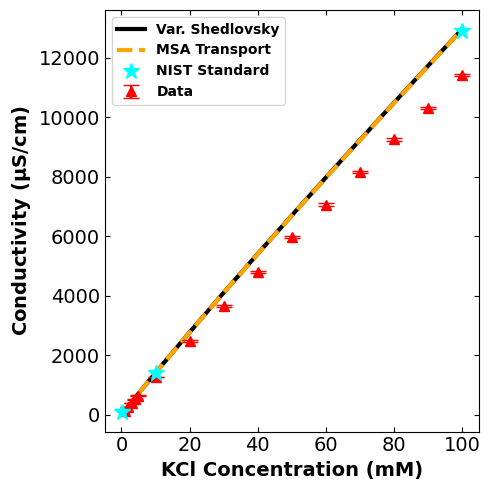

In [26]:
# making plot comparison of probe 2 uncalibrated data and the model predictions
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(molar_conc_nist, nist_cond, "*", markersize=12, color="cyan", zorder=3, label="NIST Standard")
plt.errorbar(
    molar_conc_specific, specific_cond_exp2, yerr=error_K_uncal_2, fmt='^', ecolor='red', capsize=6, markersize=7, markerfacecolor='red',
    markeredgecolor='red', label='Data')
plt.xlabel("KCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_uncal_probe2.png")
plt.show()

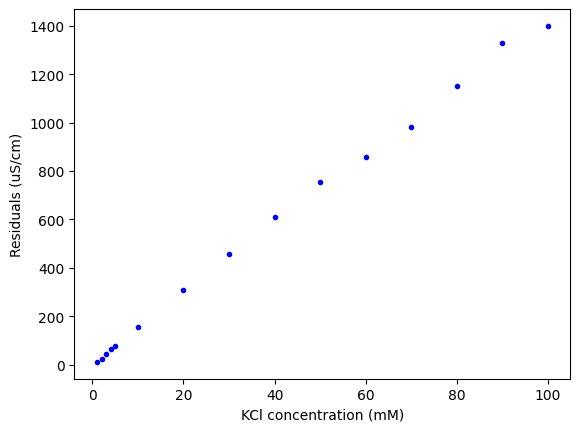

In [27]:
# residuals of the uncalibrated probe 2 data
residuals_uncal_probe2 = [specific_cond_calc[i] - specific_cond_exp2[i] for i in range(ndata_K)]

# residuals of the MSA model predictions
e_MSA_uncal_probe2 = [msa_cond_calc_kcl[i]- specific_cond_exp2[i] for i in range(ndata_K)]

# making plot of residuals of calculated specific conductivity
plt.plot(molar_conc_specific, residuals, "b.")
plt.xlabel("KCl concentration (mM)")
plt.ylabel("Residuals (uS/cm)")
plt.show()

The mean absolute percent error of Var. Shedlovsky is: 11.88704520047665
The mean absolute percent error of MSA is: 11.785213928782266


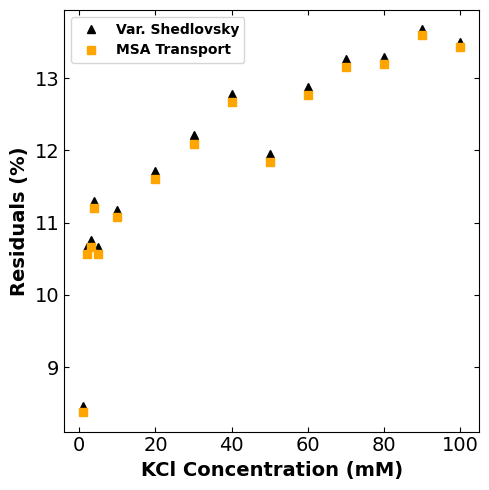

In [28]:
# residual fraction of the uncalibrated probe 2 data
e_percent_uncal_probe2 = [(residuals_uncal_probe2[i]/specific_cond_exp2[i])*100 for i in range(ndata_K)]
e_percent_MSA_uncal_probe2 = [(e_MSA_uncal_probe2[i]/specific_cond_exp2[i])*100 for i in range(ndata_K)]

# calculate the mean absolute percent error
e_percent_uncal_probe2_abs = [np.abs(e_percent_uncal_probe2[i]) for i in range(ndata_K)]
e_percent_MSA_uncal_probe2_abs = [np.abs(e_percent_MSA_uncal_probe2[i]) for i in range(ndata_K)]
e_percent_avg_probe2_uncal = np.mean(e_percent_uncal_probe2_abs)
e_percent_avg_MSA_probe2_uncal = np.mean(e_percent_MSA_uncal_probe2_abs)
print("The mean absolute percent error of Var. Shedlovsky is:",e_percent_avg_probe2_uncal)
print("The mean absolute percent error of MSA is:",e_percent_avg_MSA_probe2_uncal)

# visualizing in plot
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, e_percent_uncal_probe2, "^", color="black", label="Var. Shedlovsky")
plt.plot(molar_conc_specific, e_percent_MSA_uncal_probe2, "s", color="orange", label="MSA Transport")
plt.xlabel("KCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_residuals_uncal_probe2.png")
plt.show()

### Calibrated Data

In [29]:
specific_cond_calibrated_exp2 = specific_data_probe2["Cond Cal"]
error_K_2 = (-0.00007 * molar_conc_specific + 0.0102) * specific_cond_calibrated_exp2

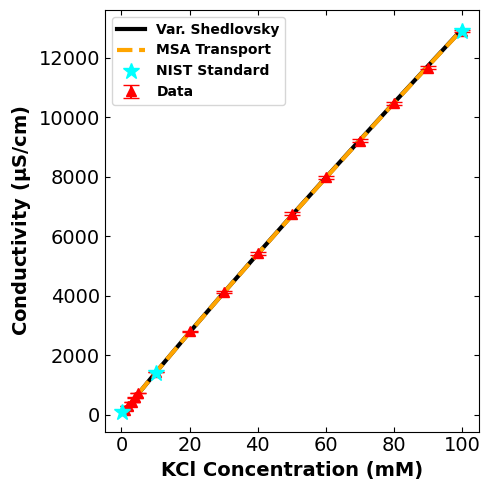

In [30]:
# making plot comparison of probe 2 uncalibrated data and the model predictions
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, specific_cond_calc, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(molar_conc_specific, msa_cond_calc_kcl, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(molar_conc_nist, nist_cond, "*", markersize=12, color="cyan", zorder=3, label="NIST Standard")
plt.errorbar(
    molar_conc_specific, specific_cond_calibrated_exp2, yerr=error_K_2, fmt='^', ecolor='red', capsize=6, markersize=7, markerfacecolor='red',
    markeredgecolor='red', label='Data')
plt.xlabel("KCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_probe2.png")
plt.show()

The mean absolute percent error of Var. Shedlovsky is: 1.1974156882726947
The mean absolute percent error of MSA is: 1.2449281447878835


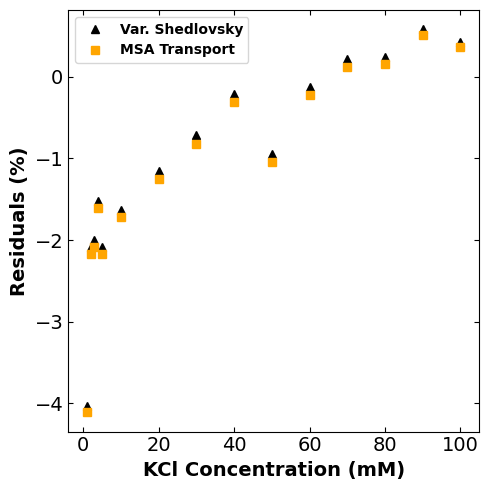

In [31]:
# residuals of the uncalibrated probe 2 data
residuals_probe2 = [specific_cond_calc[i] - specific_cond_calibrated_exp2[i] for i in range(ndata_K)]

# residuals of the MSA model predictions
e_MSA_probe2 = [msa_cond_calc_kcl[i]- specific_cond_calibrated_exp2[i] for i in range(ndata_K)]

# residual fraction of the uncalibrated probe 2 data
e_percent_probe2 = [(residuals_probe2[i]/specific_cond_calibrated_exp2[i])*100 for i in range(ndata_K)]
e_percent_MSA_probe2 = [(e_MSA_probe2[i]/specific_cond_calibrated_exp2[i])*100 for i in range(ndata_K)]

# calculate the mean absolute percent error
e_percent_probe2_abs = [np.abs(e_percent_probe2[i]) for i in range(ndata_K)]
e_percent_MSA_probe2_abs = [np.abs(e_percent_MSA_probe2[i]) for i in range(ndata_K)]
avg_e_percent_probe2_abs = np.mean(e_percent_probe2_abs)
avg_e_percent_MSA_probe2_abs = np.mean(e_percent_MSA_probe2_abs)
print("The mean absolute percent error of Var. Shedlovsky is:",avg_e_percent_probe2_abs)
print("The mean absolute percent error of MSA is:",avg_e_percent_MSA_probe2_abs)

# visualizing in plot
fig = plt.figure(figsize=(5, 5))
plt.plot(molar_conc_specific, e_percent_probe2, "^", color="black", label="Var. Shedlovsky")
plt.plot(molar_conc_specific, e_percent_MSA_probe2, "s", color="orange", label="MSA Transport")
plt.xlabel("KCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_all_residuals_probe2.png")
plt.show()